## 🔍 AIC 2026 - Thử nghiệm Vector Search trực tiếp

Notebook này cho phép bạn gõ một câu query bằng văn bản, sau đó mã hoá thành vector (qua CLIP gốc) và truy vấn trực tiếp lên Qdrant Database. Kết quả được render dưới dạng bảng Markdown trực quan.

### Kết quả truy vấn từ Qdrant Cloud với Query = `a photo of tree`:

| Rank | Score | Video ID | Frame ID | Thời điểm (s) | Clip ID | Ảnh Minh Hoạ |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **#01** | `0.2787` | L21_V031 | 9510 | 380.4s (6m 20s) | kf_106 | 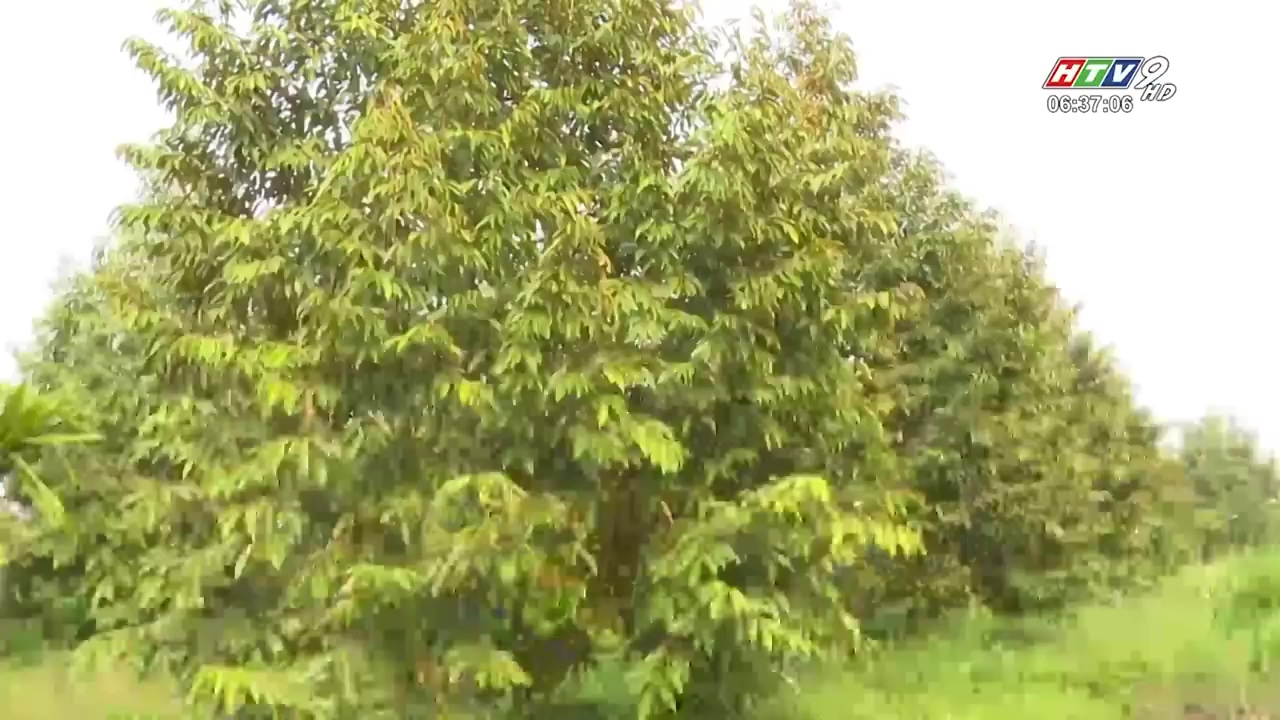 |
| **#02** | `0.2771` | L22_V009 | 8774 | 351.0s (5m 50s) | kf_101 | 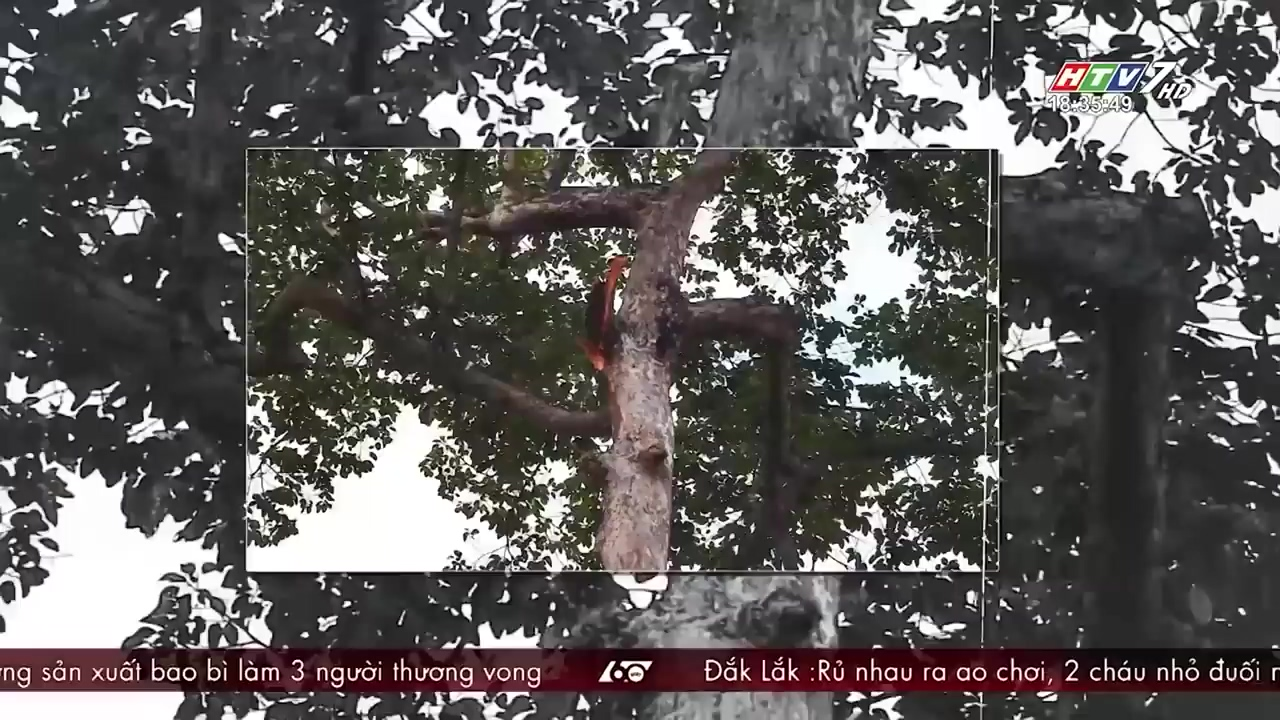 |
| **#03** | `0.2757` | L21_V014 | 5702 | 190.1s (3m 10s) | kf_050 | 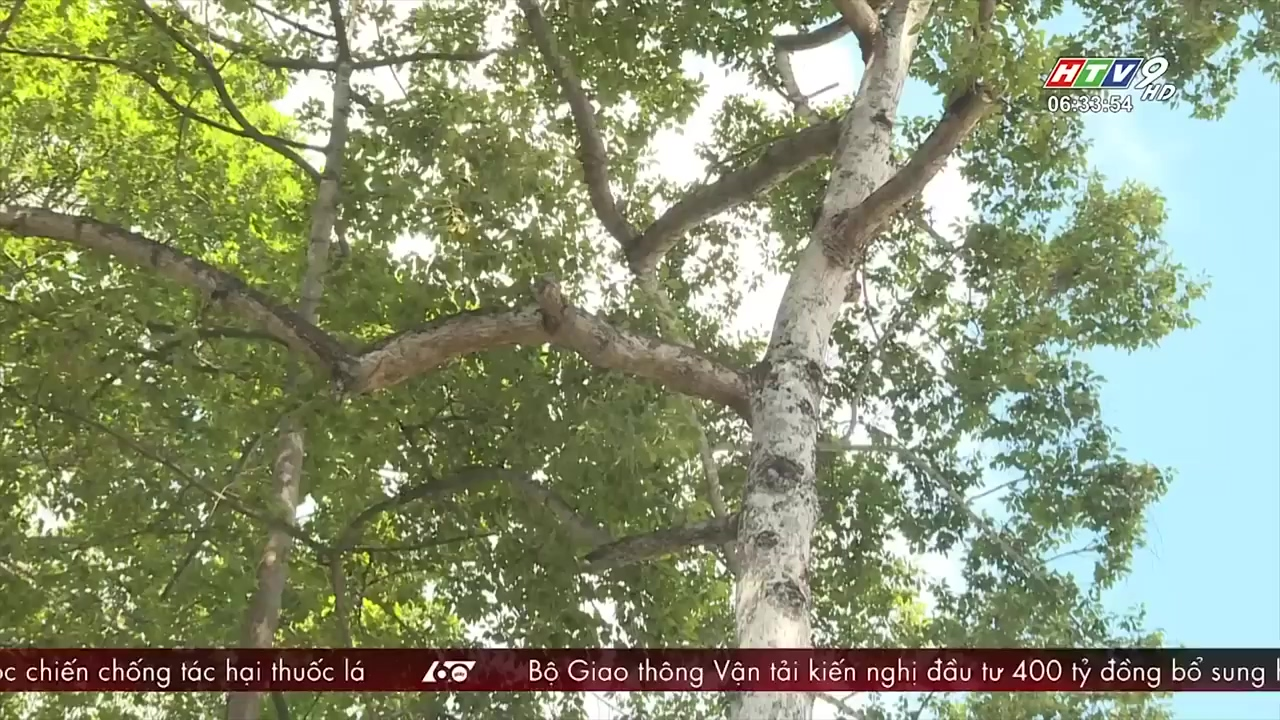 |
| **#04** | `0.2708` | L21_V021 | 10359 | 345.3s (5m 45s) | kf_089 | 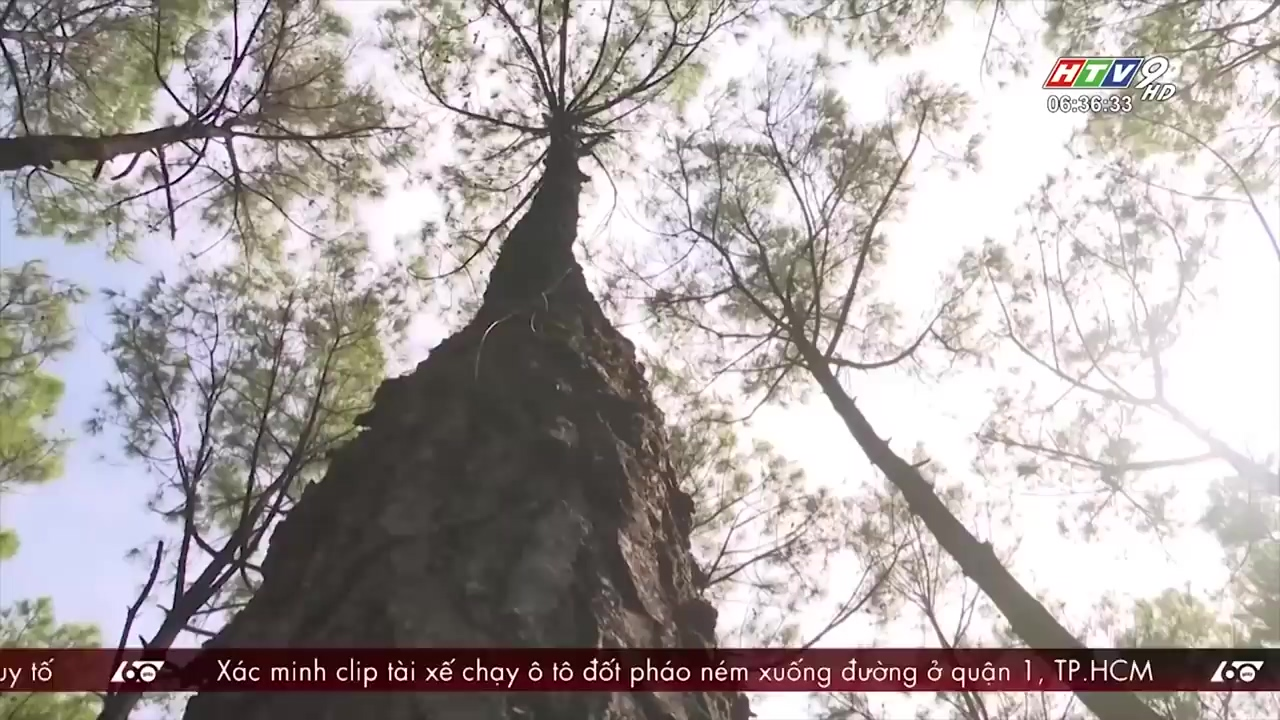 |
| **#05** | `0.2708` | L21_V007 | 6825 | 227.5s (3m 47s) | kf_058 | 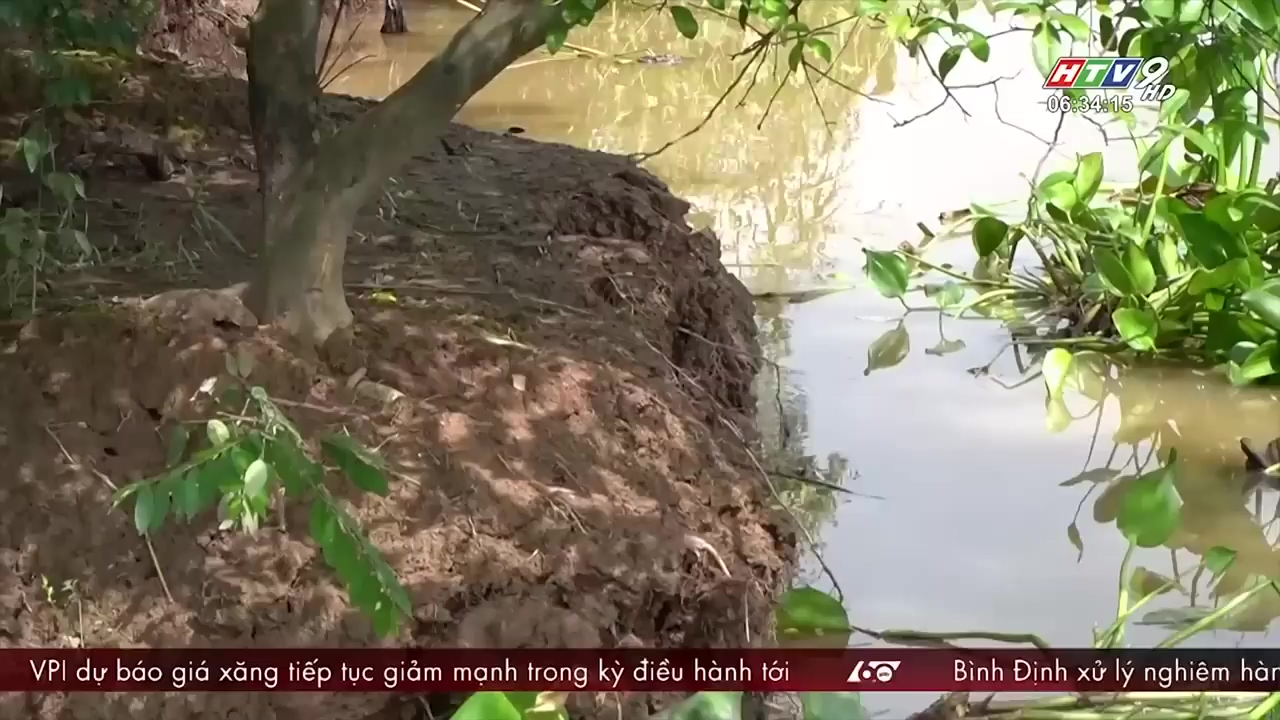 |
| **#06** | `0.2707` | L21_V031 | 9510 | 380.4s (6m 20s) | kf_107 | 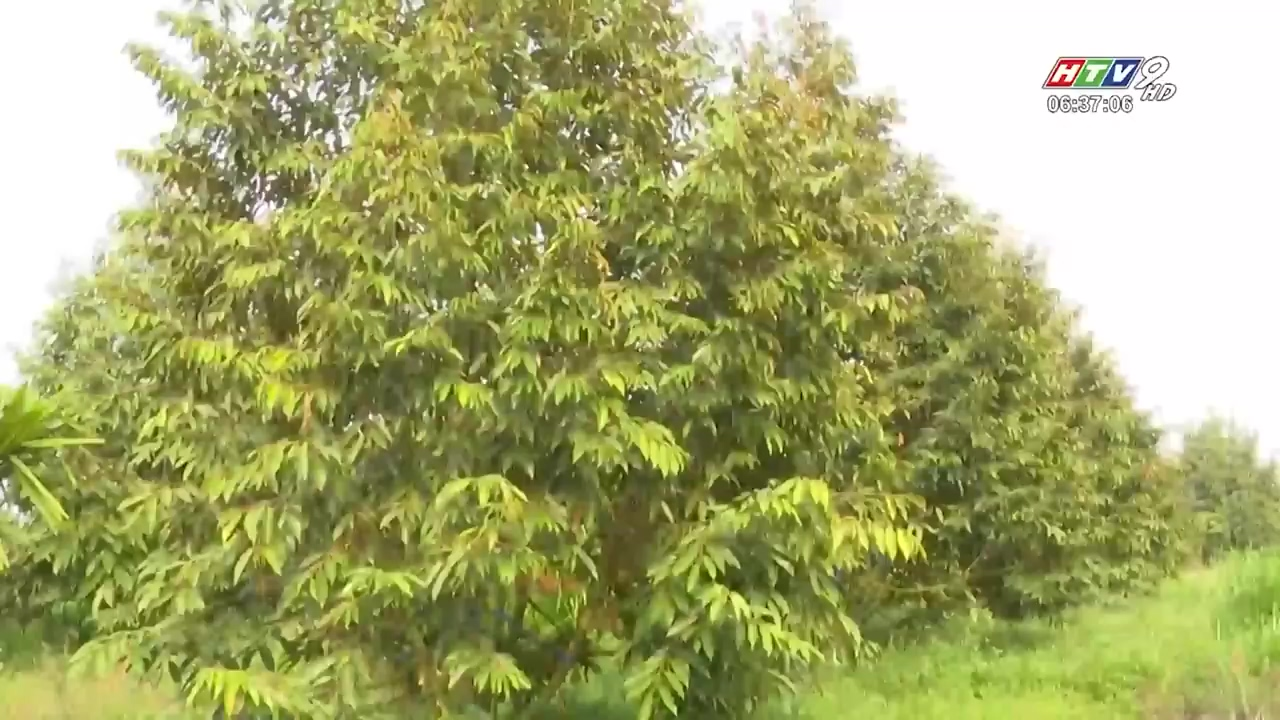 |
| **#07** | `0.2699` | L21_V017 | 6060 | 242.4s (4m 2s) | kf_060 | 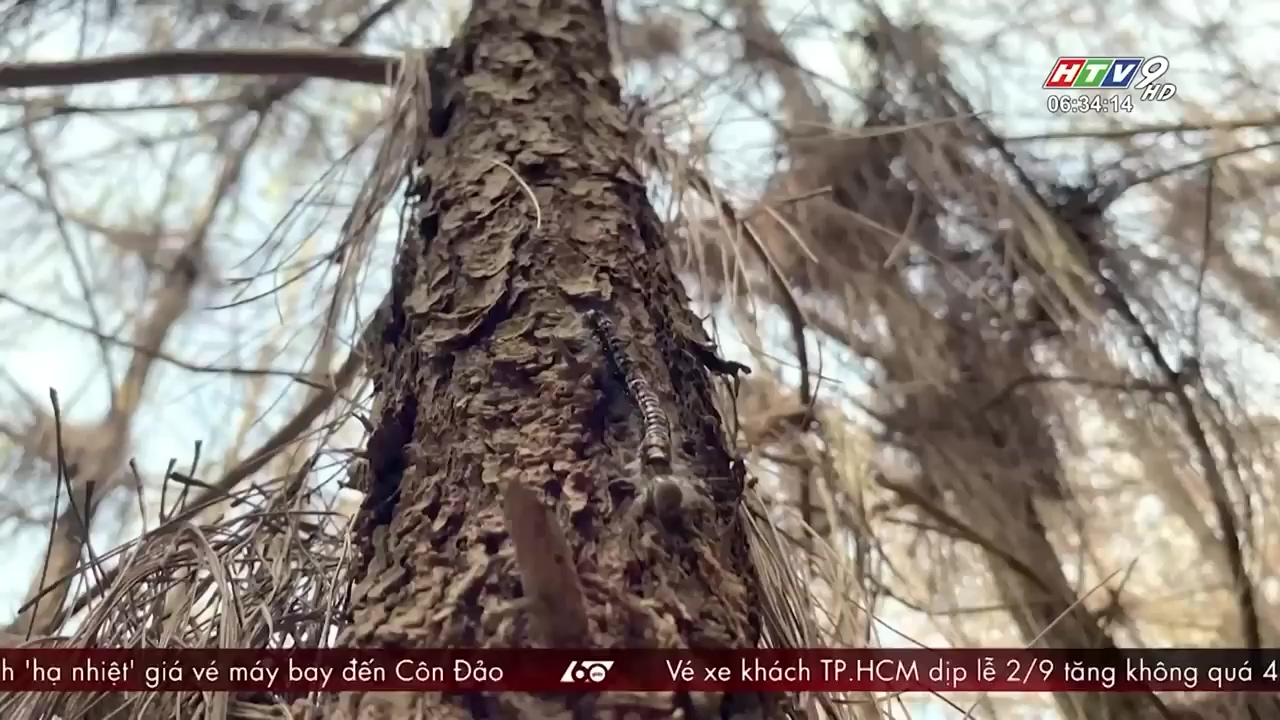 |
| **#08** | `0.2695` | L21_V019 | 8856 | 295.2s (4m 55s) | kf_078 | 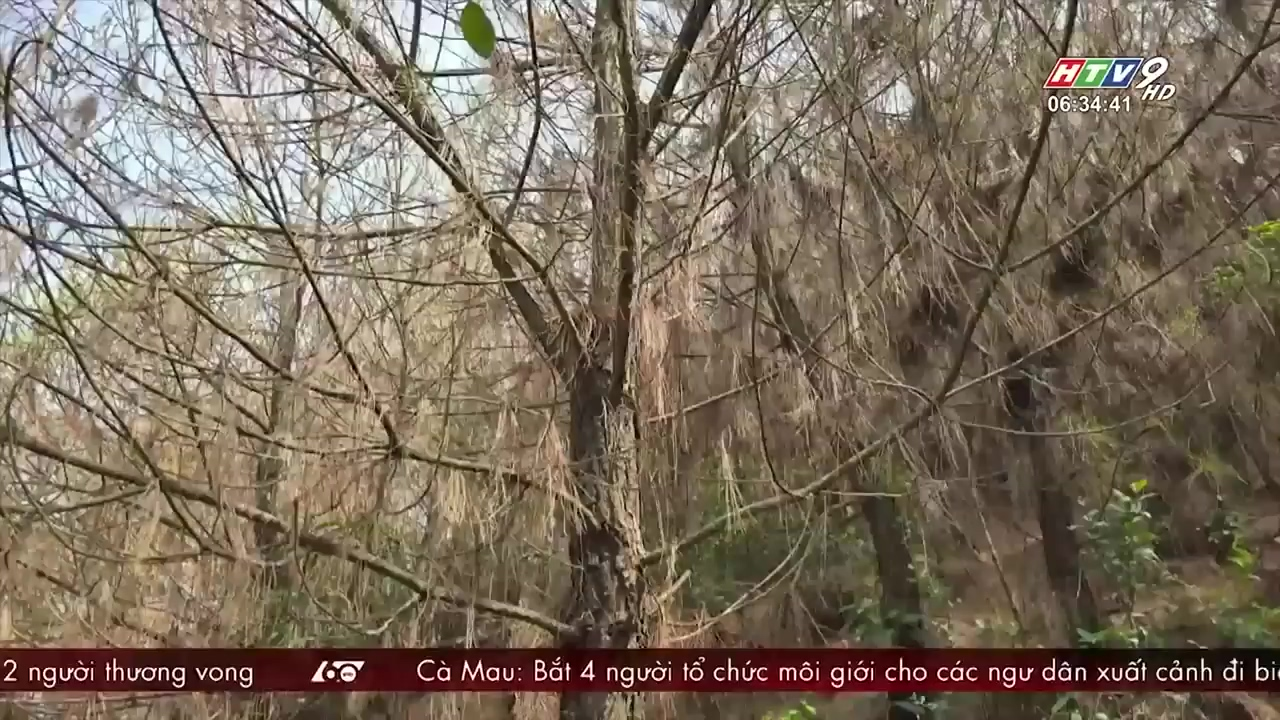 |
| **#09** | `0.2673` | L22_V014 | 6318 | 210.6s (3m 30s) | kf_058 | 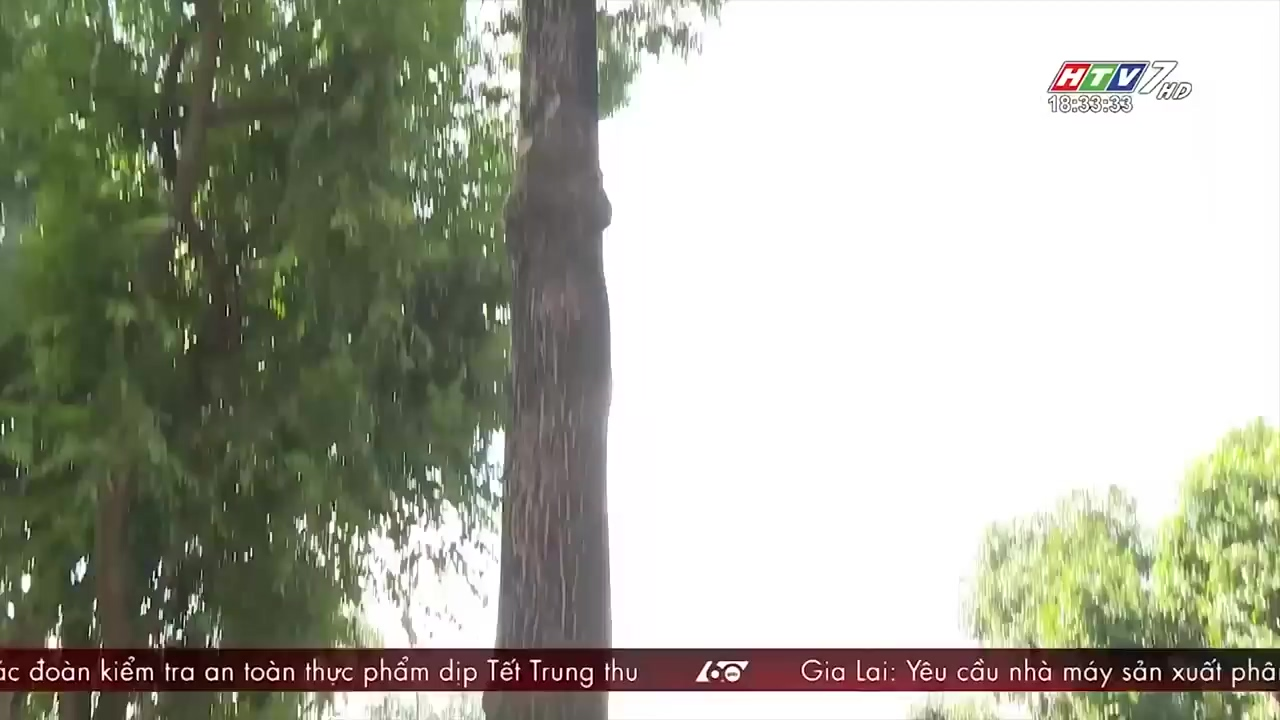 |
| **#10** | `0.2670` | L21_V012 | 4025 | 134.2s (2m 14s) | kf_036 | 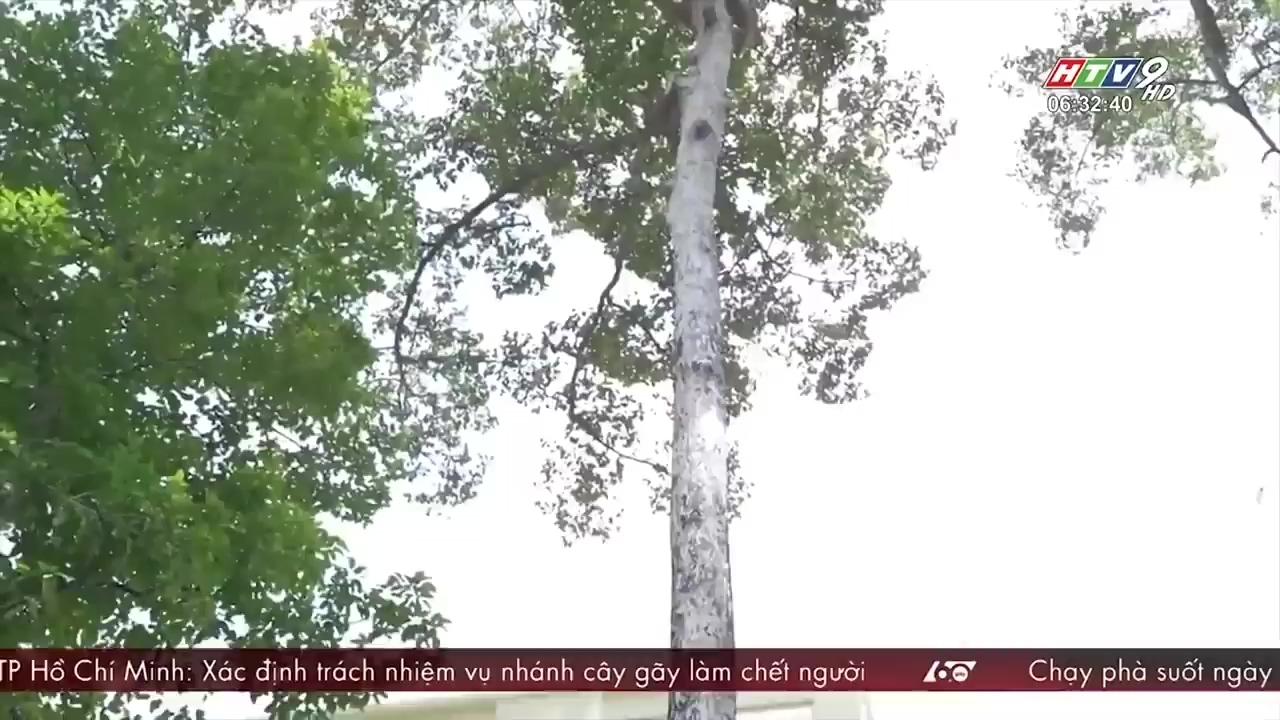 |


In [6]:
import sys
import os
import base64
import pandas as pd
from IPython.display import display, Markdown
from backend.embedding.clip_encoder import encode_text_raw
from backend.embedding.remote_index import search_remote

# 1. Đặt câu truy vấn tại đây
QUERY = "a photo of tree"
TOP_K = 10

# 2. Mã hoá câu truy vấn thành Vector 512 chiều (CLIP thô - Cực kỳ thông minh về Zero-shot)
query_vector = encode_text_raw(QUERY)

# 3. Gọi hàm search từ Qdrant
results = search_remote(query_vector=query_vector, top_k=TOP_K)

# 4. Hiển thị kết quả dạng bảng Markdown đẹp mắt
markdown_str = f"### Kết quả truy vấn từ Qdrant Cloud với Query = `{QUERY}`:\n\n"
markdown_str += "| Rank | Score | Video ID | Frame ID | Thời điểm (s) | Clip ID | Ảnh Minh Hoạ |\n"
markdown_str += "| :---: | :---: | :---: | :---: | :---: | :---: | :---: |\n"

for idx, res in enumerate(results):
    rank = f"**#{idx+1:02d}**"
    score = f"`{res.get('score', 0.0):.4f}`"
    vid = res.get('video_id', '')
    fid = res.get('frame_id', '')
    
    # Tính phút/giây dựa vào pts_time thay vì timestamp
    pts = res.get('pts_time', 0.0)
    m = int(pts // 60)
    s = int(pts % 60)
    pts_str = f"{pts:.1f}s ({m}m {s}s)"
    
    cid = res.get('clip_id', '')
    
    # Xử lý ảnh Base64 để hiển thị vượt tường lửa trình duyệt
    path = res.get('path', '')
    img_tag = "Không có ảnh"
    if path and os.path.exists(path):
        with open(path, "rb") as img_file:
            b64_string = base64.b64encode(img_file.read()).decode('utf-8')
            img_tag = f"<img src='data:image/jpeg;base64,{b64_string}' width='160' style='border-radius: 8px;' />"
    elif path:
        img_tag = f"Lỗi file ảnh: {path}"

    markdown_str += f"| {rank} | {score} | {vid} | {fid} | {pts_str} | {cid} | {img_tag} |\n"

display(Markdown(markdown_str))
